# Importing External Data into TorchSig: SIGMF Example
This notebook shows an example of how to import externally created data into TorchSig using a basic gnuradio generated SIGMF dataset with JSON metadata file format. 

This example employs a provided `SigMFReader` subclass of TorchSig's `FileReader` to read a custom externally created dataset as a `StaticTorchSigDataset`.

---

In [29]:
# gnuradio depends on numpy<2
import sys
!{sys.executable} -m pip install "numpy<2" --force-reinstall

  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
tifffile 2026.6.1 requires numpy>=2.1, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
imagecodecs 2026.6.6 requires numpy>=2.1, but you have numpy 1.26.4 which is incompatible.
torchsig 2.2.0 requires numpy>=2, but you have numpy 

In [30]:
import sys
from pathlib import Path

examples_dir = Path.cwd().parents[0]
repo_root = examples_dir.parent

sys.path.insert(0, str(repo_root))

In [31]:
# ----------------------------------------------------------------------
# 1️⃣  Standard‑library imports
# ----------------------------------------------------------------------
import csv
import json
import math
import os

# ----------------------------------------------------------------------
# 2️⃣  Third‑party imports
# ----------------------------------------------------------------------
import matplotlib.pyplot as plt
import numpy as np
import scipy.signal as signal
import torch

# ----------------------------------------------------------------------
# 3️⃣  TorchSig (local / project‑specific) imports
# ----------------------------------------------------------------------
from torchsig.datasets.datasets import StaticTorchSigDataset
from torchsig.transforms.transforms import ComplexTo2D
from torchsig.utils.file_handlers.sigmf import SigMFReader

sys.path.insert(0, "/usr/lib/python3/dist-packages")

from examples.scripts.generate_gnuradio_examples import IQDatasetGenerator

## Step 1: External Data Generation Process: create synthetic data outside TorchSig workflow

If your data already exists somewhere, you can skip to Step 2.

We will write a sample dataset using gnuradio generated .wav for signal data and and csv for metadata. 

### External Synthetic Data and Metadata Generation

In [32]:
# configuration parameters
root = "../datasets/sigmf_example"  # data file top-level folder
seed = 1234567890  # rng seed

os.makedirs(root, exist_ok=True)  # directory for files

Below, we generate some signals (outside of TorchSig), using a gnuradio wavefile sink.

Generating /weka/apotts/forks/torchsig-github/examples/datasets/sigmf_example/BPSK/BPSK_-10dB_seed12345.sigmf-data …
Generating /weka/apotts/forks/torchsig-github/examples/datasets/sigmf_example/BPSK/BPSK_+00dB_seed12345.sigmf-data …


Generating /weka/apotts/forks/torchsig-github/examples/datasets/sigmf_example/BPSK/BPSK_+10dB_seed12345.sigmf-data …
Generating /weka/apotts/forks/torchsig-github/examples/datasets/sigmf_example/QPSK/QPSK_-10dB_seed12345.sigmf-data …
Generating /weka/apotts/forks/torchsig-github/examples/datasets/sigmf_example/QPSK/QPSK_+00dB_seed12345.sigmf-data …
Generating /weka/apotts/forks/torchsig-github/examples/datasets/sigmf_example/QPSK/QPSK_+10dB_seed12345.sigmf-data …
Generating /weka/apotts/forks/torchsig-github/examples/datasets/sigmf_example/8PSK/8PSK_-10dB_seed12345.sigmf-data …
Generating /weka/apotts/forks/torchsig-github/examples/datasets/sigmf_example/8PSK/8PSK_+00dB_seed12345.sigmf-data …
Generating /weka/apotts/forks/torchsig-github/examples/datasets/sigmf_example/8PSK/8PSK_+10dB_seed12345.sigmf-data …

✅  All WAV files and side-cars have been created.
 → metadata.csv : /weka/apotts/forks/torchsig-github/examples/datasets/sigmf_example/metadata.csv
 → info.json    : /weka/apotts/f

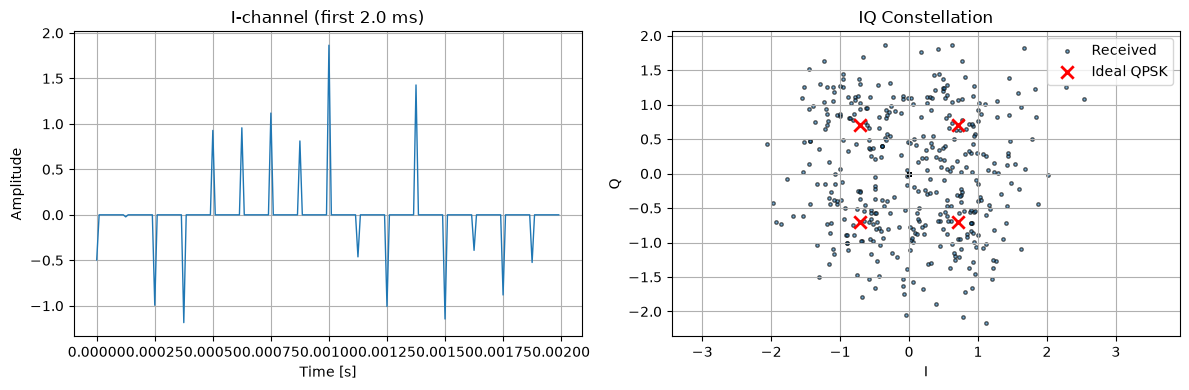

In [33]:
# --------------------------------------------------------------
# 1) Import the class
# --------------------------------------------------------------
from examples.scripts.generate_gnuradio_examples import IQDatasetGenerator

# --------------------------------------------------------------
# 2) Create an instance
# --------------------------------------------------------------
gen = IQDatasetGenerator(
    root=root,
    snr_db=[-10, 0, 10],
    duration_s=0.5,
    audio_rate=96_000,
    seed=12345,
    output_format="sigmf",
)

# --------------------------------------------------------------
# 3) Build the whole data set (this will take a few seconds)
# --------------------------------------------------------------
gen.generate()   # creates the WAVs + metadata.csv + info.json

# --------------------------------------------------------------
# 4) Quick visual sanity‑check
# --------------------------------------------------------------
gen.plot_example(mod="QPSK", snr=0)  # shows the first 2 ms + constellation

Let's verify the data that was written.

In [34]:
example_paths = [
    "BPSK/BPSK_+00dB_seed12345.sigmf-data",
    "BPSK/BPSK_+10dB_seed12345.sigmf-data",
    "BPSK/BPSK_-10dB_seed12345.sigmf-data",
    "8PSK/8PSK_+00dB_seed12345.sigmf-data",
    "8PSK/8PSK_+10dB_seed12345.sigmf-data",
    "8PSK/8PSK_-10dB_seed12345.sigmf-data",
    "QPSK/QPSK_+00dB_seed12345.sigmf-data",
    "QPSK/QPSK_+10dB_seed12345.sigmf-data",
    "QPSK/QPSK_-10dB_seed12345.sigmf-data",
]

In [35]:
data_path = Path(root) / example_paths[0]
meta_path = data_path.with_suffix(".sigmf-meta")

with meta_path.open() as f:
    sigmf_meta = json.load(f)

iq = np.fromfile(data_path, dtype=np.complex64)

print("SigMF data file :", data_path)
print("SigMF meta file :", meta_path)
print("Datatype        :", sigmf_meta["global"]["core:datatype"])
print("Sample rate     :", sigmf_meta["global"]["core:sample_rate"])
print("Num IQ samples  :", iq.shape[0])

with open(Path(root) / "info.json") as f:
    info = json.load(f)

print("Expected num_iq_samples from info.json :", info["num_iq_samples"])

SigMF data file : ../datasets/sigmf_example/BPSK/BPSK_+00dB_seed12345.sigmf-data
SigMF meta file : ../datasets/sigmf_example/BPSK/BPSK_+00dB_seed12345.sigmf-meta
Datatype        : cf32_le
Sample rate     : 96000
Num IQ samples  : 48000
Expected num_iq_samples from info.json : 48000


In [36]:
def quick_plot_sigmf(sigmf_data_path: str | Path) -> None:
    sigmf_data_path = Path(sigmf_data_path)
    sigmf_meta_path = sigmf_data_path.with_suffix(".sigmf-meta")

    with sigmf_meta_path.open() as f:
        meta = json.load(f)

    sample_rate = meta["global"]["core:sample_rate"]
    datatype = meta["global"]["core:datatype"]

    if datatype != "cf32_le":
        raise ValueError(f"This quick plot only supports cf32_le, got {datatype}")

    cvec = np.fromfile(sigmf_data_path, dtype=np.complex64)

    t = np.arange(len(cvec)) / sample_rate

    plt.figure(figsize=(8, 2))
    plt.plot(t[:2000], cvec.real[:2000])
    plt.title(sigmf_data_path.name)
    plt.xlabel("Time (s)")
    plt.ylabel("I amplitude")
    plt.grid(True)
    plt.show()

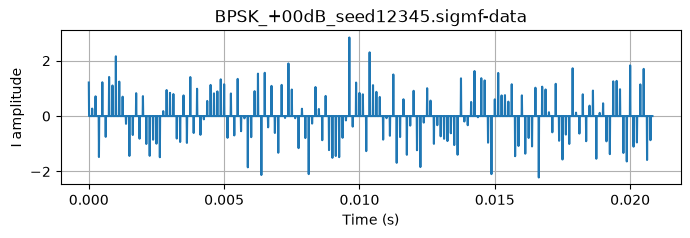

In [37]:
quick_plot_sigmf(Path(root) / example_paths[0])

In [38]:
def plot_iq_sigmf(sigmf_data_path: str | Path) -> None:
    sigmf_data_path = Path(sigmf_data_path)
    sigmf_meta_path = sigmf_data_path.with_suffix(".sigmf-meta")

    if not sigmf_data_path.is_file():
        raise FileNotFoundError(f"File not found: {sigmf_data_path}")

    with sigmf_meta_path.open() as f:
        meta = json.load(f)

    sample_rate = meta["global"]["core:sample_rate"]
    datatype = meta["global"]["core:datatype"]

    if datatype != "cf32_le":
        raise ValueError(f"This plot helper only supports cf32_le, got {datatype}")

    cvec = np.fromfile(sigmf_data_path, dtype=np.complex64)

    i = cvec.real
    q = cvec.imag

    t = np.arange(len(i)) / sample_rate
    n_plot = int(0.002 * sample_rate)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(t[:n_plot], i[:n_plot], lw=1)
    plt.title("I-channel (first 2 ms)")
    plt.xlabel("Time [s]")
    plt.ylabel("Amplitude")
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.scatter(i, q, s=6, alpha=0.6, edgecolors="k", label="Received symbols")
    plt.title("IQ Constellation")
    plt.xlabel("I (real)")
    plt.ylabel("Q (imag)")
    plt.axis("equal")
    plt.grid(True)

    plt.tight_layout()
    plt.show()


Plotting ../datasets/sigmf_example/BPSK/BPSK_+00dB_seed12345.sigmf-data


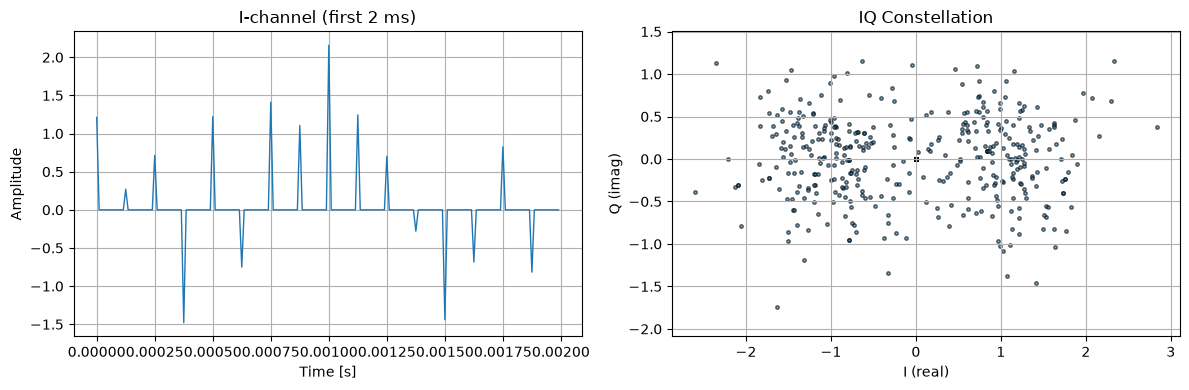

In [39]:
example_path = Path(root) / example_paths[0]
print(f"Plotting {example_path}")
plot_iq_sigmf(example_path)

## Step 2: StaticTorchSigDataset

Use `StaticTorchSigDataset` and a file handler to interface with the dataset.

In [40]:
example_idx = 7

In [41]:
custom_dataset = StaticTorchSigDataset(
    file_handler_class=SigMFReader,
    root=root,
    transforms=[ComplexTo2D()],
    target_labels=["modcod"],
)

print(f"Dataset size: {len(custom_dataset)}")

data, label = custom_dataset[example_idx]
print(f"Data element shape: {data.shape}")
print(f"Label: {label}")
print(data)

Dataset size: 9
Data element shape: (2, 48000)
Label: 2
[[-0.6402206  0.         0.        ...  0.         0.         0.       ]
 [-0.9874567  0.         0.        ...  0.         0.         0.       ]]


## Step 3: Visualize

Note: The flat-zero region at the end of the trace is normal. It is zero-padding used to ensure every record has a fixed length for batch processing. This does not indicate a signal error and can be ignored during visualization.

Label (modcod) = 2
data.shape = (2, 48000)


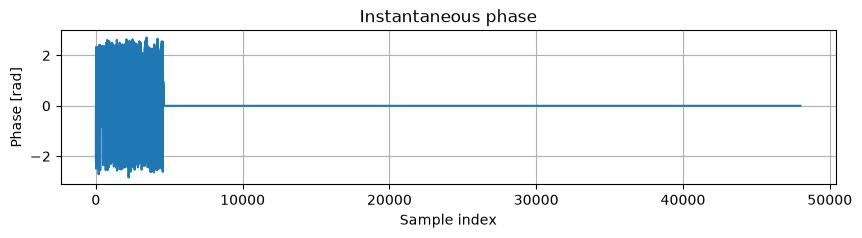

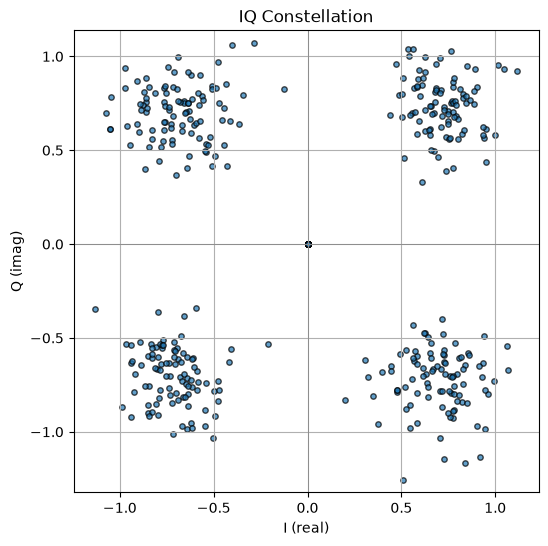

In [42]:
idx = example_idx
data, label = custom_dataset[idx]

print(f"Label (modcod) = {label}")
print(f"data.shape = {data.shape}")

if isinstance(data, torch.Tensor):
    data_np = data.cpu().numpy()
else:
    data_np = np.asarray(data)

I, Q = data_np[0], data_np[1]
cvec = I + 1j * Q

cvec = cvec / np.sqrt(np.mean(np.abs(cvec) ** 2))

phase = np.angle(cvec)

plt.figure(figsize=(10, 2))
plt.plot(phase, label="phase (rad)")
plt.title("Instantaneous phase")
plt.xlabel("Sample index")
plt.ylabel("Phase [rad]")
plt.grid(True)
plt.show()

max_abs = max(abs(I).max(), abs(Q).max())
margin = 0.2 * max_abs

plt.figure(figsize=(6, 6))
plt.scatter(I, Q, s=15, alpha=0.7, edgecolors="k")
plt.title("IQ Constellation")
plt.xlabel("I (real)")
plt.ylabel("Q (imag)")

plt.xlim(-max_abs - margin, max_abs + margin)
plt.ylim(-max_abs - margin, max_abs + margin)

plt.axhline(0, color="gray", linewidth=0.5)
plt.axvline(0, color="gray", linewidth=0.5)
plt.grid(True)
plt.axis("equal")
plt.show()